In [1]:
!git clone https://github.com/mtaarik/textual-inversion-generative-ai.git

Cloning into 'textual-inversion-generative-ai'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 77 (delta 9), reused 67 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 15.28 MiB | 28.40 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [2]:
cd textual-inversion-generative-ai

/content/textual-inversion-generative-ai


In [3]:
!pip install diffusers transformers accelerate safetensors ftfy datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00


In [4]:
!pip install git+https://github.com/huggingface/diffusers

  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-e2boz88_
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-e2boz88_
  Resolved https://github.com/huggingface/diffusers to commit 1d6199345801af2176f12596e9546353d7bbcb9b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.1/516.1 kB 20.7 MB/s eta 0:00:00
  Created wheel for diffusers: filename=diffusers-0.39.0.dev0-py3-none-any.whl size=5485774 sha256=8f196331fffe37b8dc16cc043c8b0e85df00bb71fc19916354420a5c16427be0
  Stored in directory: /tmp/pip-ephem-wheel-cache-3903g1ka/wheels/90/d4/44/a58bc00fb405fefb633b0d9d2307f6e3aec6cc1775d82555d3
Successfully built diffusers
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled sa

In [5]:
!wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/textual_inversion/textual_inversion.py

--2026-06-02 22:10:27--  https://raw.githubusercontent.com/huggingface/diffusers/main/examples/textual_inversion/textual_inversion.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40645 (40K) [text/plain]
Saving to: ‘textual_inversion.py’

textual_inversion.p 100%[===================>]  39.69K  --.-KB/s    in 0s      

2026-06-02 22:10:27 (145 MB/s) - ‘textual_inversion.py’ saved [40645/40645]



In [6]:
import os

dataset_path = "dataset/processed"

image_files = [
    f for f in os.listdir(dataset_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

num_images = len(image_files)

print("Nombre d'images utilisées :", num_images)
print(image_files)

Nombre d'images utilisées : 10
['processed_04.jpeg', 'processed_00.jpeg', 'processed_09.jpeg', 'processed_05.jpeg', 'processed_01.jpeg', 'processed_08.jpeg', 'processed_03.jpeg', 'processed_07.jpeg', 'processed_02.jpeg', 'processed_06.jpeg']


In [7]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [8]:
placeholder_token = "<toycar>"

In [10]:
import time

start_time = time.time()

!accelerate launch textual_inversion.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="dataset/processed" \
  --learnable_property="object" \
  --placeholder_token="<toycar>" \
  --initializer_token="toy" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --max_train_steps=1000 \
  --learning_rate=5.0e-04 \
  --output_dir="textual_inversion_output"

end_time = time.time()

ti_training_time_minutes = (end_time - start_time) / 60
print(f"Temps d'entraînement Textual Inversion : {ti_training_time_minutes:.2f} minutes")

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
{'prediction_type', 'dynamic_thresholding_ratio', 'samp

In [11]:
!du -h textual_inversion_output
!du -h textual_inversion_output/learned_embeds.safetensors

759M	textual_inversion_output/checkpoint-500
759M	textual_inversion_output/checkpoint-1000
8.0K	textual_inversion_output/logs/textual_inversion/1780438486.6654358
8.0K	textual_inversion_output/logs/textual_inversion/1780438486.6638165
8.0K	textual_inversion_output/logs/textual_inversion/1780438386.2570374
8.0K	textual_inversion_output/logs/textual_inversion/1780438386.2587664
372K	textual_inversion_output/logs/textual_inversion
376K	textual_inversion_output/logs
1.5G	textual_inversion_output
4.0K	textual_inversion_output/learned_embeds.safetensors


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


  0%|          | 0/50 [00:00<?, ?it/s]

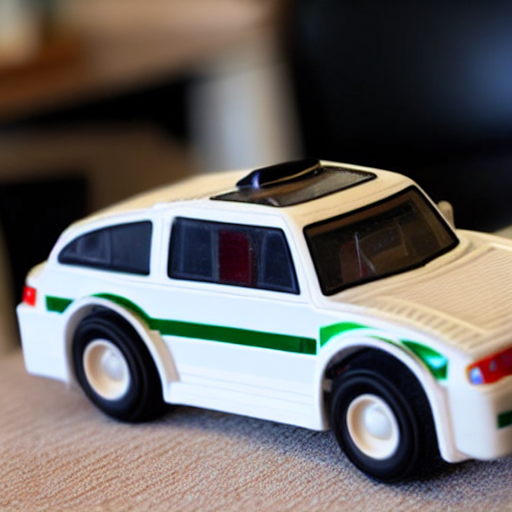

In [12]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")
pipe.load_textual_inversion("textual_inversion_output")

prompt = "a photo of <toycar> on a table"

image = pipe(prompt).images[0]
image.save("results/textual_inversion/result1.png")
image

  0%|          | 0/50 [00:00<?, ?it/s]

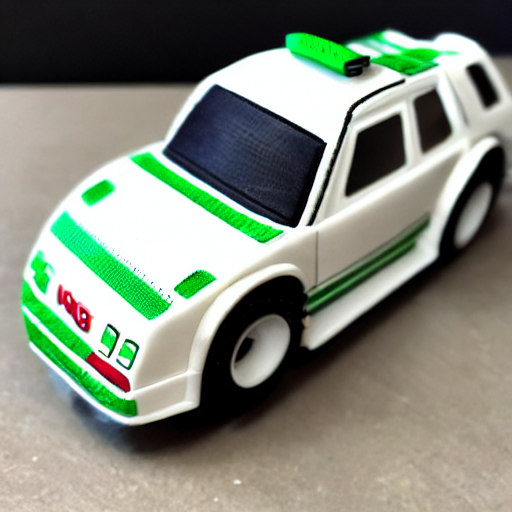

In [13]:
prompt = "a cartoon style <toycar>"

image = pipe(prompt).images[0]
image.save("results/textual_inversion/result2.png")
image

  0%|          | 0/50 [00:00<?, ?it/s]

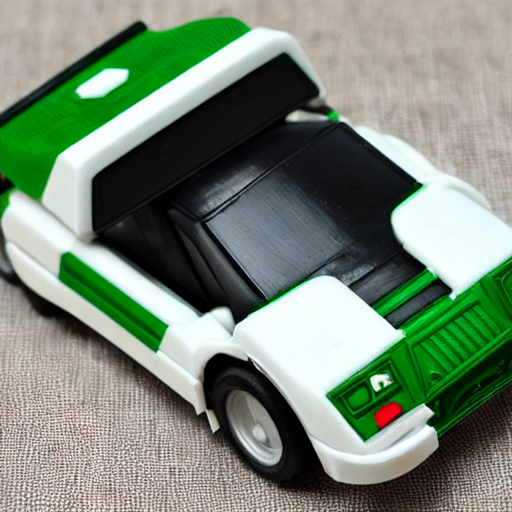

In [14]:
prompt = "a futuristic <toycar>"

image = pipe(prompt).images[0]
image.save("results/textual_inversion/result3.png")
image

  0%|          | 0/50 [00:00<?, ?it/s]

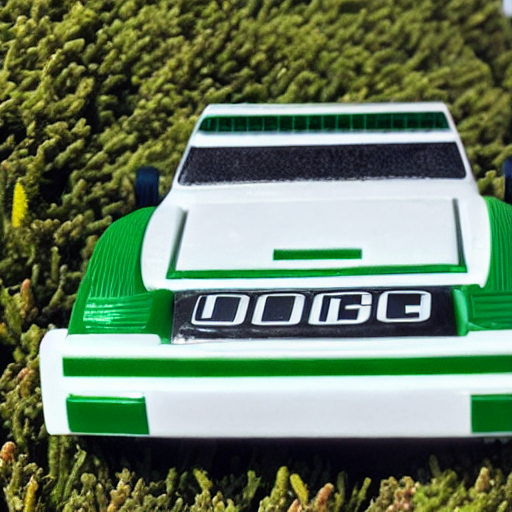

In [15]:
prompt = "a photo of <toycar> in a garden"

image = pipe(prompt).images[0]
image.save("results/textual_inversion/result4.png")
image

In [16]:
from google.colab import files

files.download("results/textual_inversion/result1.png")
files.download("results/textual_inversion/result2.png")
files.download("results/textual_inversion/result3.png")
files.download("results/textual_inversion/result4.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
files.download("textual_inversion_output/learned_embeds.safetensors")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>